In [1]:
import jos3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [2]:
ALL_SEGMENTS = [
    "Head", "Neck", "Chest", "Back", "Pelvis",
    "LShoulder", "LArm", "LHand",
    "RShoulder", "RArm", "RHand",
    "LThigh", "LLeg", "LFoot",
    "RThigh", "RLeg", "RFoot",
]

DISPLAY_SEGMENTS = [
    "Head", "Neck", "Chest", "Back", "Pelvis",
    "LShoulder", "LArm", "LHand",
    "LThigh", "LLeg", "LFoot",
]


BACK_SEG_IDX  = 3
CHEST_SEG_IDX = 2
T_COOL_THRESHOLD = 34.8
T_HEAT_THRESHOLD = 33.0
COOL_POWER       = -50.0
HEAT_POWER       = +50.0

In [ ]:
########## fonction de contrôle : palier progressif  ##########


STEP_W    = 5.0    # W par palier
STEP_DEG  = 0.1    # degré par palier
MAX_STEPS = 10     

def apply_device(model: jos3.JOS3, t_cool=T_COOL_THRESHOLD, t_heat=T_HEAT_THRESHOLD):
    tsk   = float(model.Tsk[CHEST_SEG_IDX])
    Q_ext = np.zeros(17)

    if tsk > t_cool:
        ecart  = tsk - t_cool
        palier = min(int(np.ceil(ecart / STEP_DEG)), MAX_STEPS)
        Q_ext[BACK_SEG_IDX] = -palier * STEP_W

    elif tsk < t_heat:
        ecart  = t_heat - tsk
        palier = min(int(np.ceil(ecart / STEP_DEG)), MAX_STEPS)
        Q_ext[BACK_SEG_IDX] = +palier * STEP_W

    model._set_ex_q("skin", Q_ext)
    return float(Q_ext[BACK_SEG_IDX])

In [5]:
# Profils utilisateurs

profile_sport = dict(height=1.78, weight=72, fat=12, age=28, sex="male",
                     bmr_equation="harris-benedict", bsa_equation="dubois", ex_output="all")

profile_sep = dict(height=1.65, weight=65, fat=28, age=45, sex="female",
                   bmr_equation="harris-benedict", bsa_equation="dubois", ex_output="all")

profile_dialyse = dict(height=1.72, weight=75, fat=24, age=68, sex="male",
                       bmr_equation="harris-benedict", bsa_equation="dubois", ex_output="all")


# Vêtements sportifs
icl_sport = np.array([
    0.00, 0.00, 0.20, 0.20, 0.25,
    0.10, 0.10, 0.00,
    0.10, 0.10, 0.00,
    0.10, 0.10, 0.00,
    0.10, 0.10, 0.00,
])

# Vêtements SEP
icl_sep = np.array([
    0.00, 0.10, 0.35, 0.35, 0.35,
    0.25, 0.25, 0.05,
    0.25, 0.25, 0.05,
    0.30, 0.25, 0.10,
    0.30, 0.25, 0.10,
])

# Vêtements dialyse
icl_dialyse = np.array([
    0.00, 0.05, 0.20, 0.20, 0.20,
    0.10, 0.05, 0.00,
    0.10, 0.05, 0.00,
    0.30, 0.25, 0.10,
    0.30, 0.25, 0.10,
])

In [6]:


phases_sport = [
    dict(name="Course intense au soleil",
         times=30, dtime=60,
         Ta=32.0, Tr=45.0, RH=40.0, Va=0.8, PAR=6.0, posture="standing"),
    dict(name="Arrêt à l'ombre",
         times=10, dtime=60,
         Ta=24.0, Tr=24.0, RH=50.0, Va=0.2, PAR=1.2, posture="standing"),
    dict(name="Sprint final",
         times=15, dtime=60,
         Ta=30.0, Tr=38.0, RH=45.0, Va=0.6, PAR=8.0, posture="standing"),
]

phases_sep = [
    dict(name="Repos avant séance",
         times=5, dtime=60,
         Ta=24.0, Tr=24.0, RH=50.0, Va=0.1, PAR=1.0, posture="sitting"),
    dict(name="Échauffement léger",
         times=10, dtime=60,
         Ta=24.0, Tr=24.0, RH=50.0, Va=0.1, PAR=2.0, posture="standing"),
    dict(name="Exercices kiné soutenus",
         times=35, dtime=60,
         Ta=24.0, Tr=24.0, RH=50.0, Va=0.1, PAR=4.0, posture="standing"),
    dict(name="Récupération",
         times=10, dtime=60,
         Ta=24.0, Tr=24.0, RH=50.0, Va=0.1, PAR=1.2, posture="sitting"),
]

phases_dialyse = [
    dict(name="Installation",
         times=10, dtime=60,
         Ta=22.0, Tr=22.0, RH=45.0, Va=0.15, PAR=1.0, posture="sitting"),
    dict(name="Début séance",
         times=60, dtime=60,
         Ta=21.0, Tr=21.0, RH=45.0, Va=0.15, PAR=1.0, posture="sitting"),
    dict(name="Mi-séance (frissons)",
         times=90, dtime=60,
         Ta=21.0, Tr=21.0, RH=45.0, Va=0.15, PAR=1.0, posture="sitting"),
    dict(name="Fin de séance",
         times=30, dtime=60,
         Ta=22.0, Tr=22.0, RH=45.0, Va=0.10, PAR=1.0, posture="sitting"),
]

In [ ]:

###### Simulation

def run_scenario(profile, icl, phases, perte_core_W=0.0, phases_pertes=None,
                 t_cool=T_COOL_THRESHOLD, t_heat=T_HEAT_THRESHOLD):

    model = jos3.JOS3(**profile)

    results = dict(time_min=[], phase=[], Tcb=[], TskMean=[], power_back=[])
    for seg in ALL_SEGMENTS:
        results[f"Tsk_{seg}"] = []

    elapsed_min      = 0.0
    phase_boundaries = [0]

    for i_phase, phase in enumerate(phases):
        print(f"\n  {phase['name']}")
        print(f"  Ta={phase['Ta']}°C | Tr={phase['Tr']}°C | PAR={phase['PAR']} | VA = {phase['Va']} | {phase['times']} min")

        model.Ta      = phase["Ta"]
        model.Tr      = phase["Tr"]
        model.RH      = phase["RH"]
        model.Va      = phase["Va"]
        model.PAR     = phase["PAR"]
        model.posture = phase["posture"]
        model.Icl     = icl

        for _ in range(phase["times"]):
            power = apply_device(model, t_cool=t_cool, t_heat=t_heat)

            if perte_core_W != 0.0 and phases_pertes is not None and i_phase in phases_pertes:
                Q_core = np.zeros(17)
                Q_core[CHEST_SEG_IDX] = -perte_core_W / 2
                Q_core[4] = -perte_core_W / 2
                model._set_ex_q("core", Q_core)

            model.simulate(times=1, dtime=phase["dtime"])

            elapsed_min += phase["dtime"] / 60.0
            results["time_min"].append(elapsed_min)
            results["phase"].append(phase["name"])
            results["Tcb"].append(float(model.Tcb))
            results["TskMean"].append(float(model.TskMean))
            results["power_back"].append(power)

            for i, seg in enumerate(ALL_SEGMENTS):
                results[f"Tsk_{seg}"].append(float(model.Tsk[i]))

        phase_boundaries.append(elapsed_min)

    df = pd.DataFrame(results)

    # Scoring totalement arbitraire, on a décidé de prendre en compte que la correlation lineaire entre Tcb et les autres temperatures de peau,
    #  on aurait pu prendre en compte le bruit et potentiellement un decalage temporel

    tcb_series    = df["Tcb"]
    sensor_scores = {}
    for seg in DISPLAY_SEGMENTS:

        sensor_scores[seg] = abs(df[f"Tsk_{seg}"].corr(tcb_series, method="pearson"))


    ranked = sorted(sensor_scores.items(), key=lambda x: -x[1])
    top5   = [seg for seg, _ in ranked[:5]]

    return df, phase_boundaries, sensor_scores, ranked, top5

In [8]:
print("=== SPORT ===")
df_sport, pb_sport, scores_sport, ranked_sport, top5_sport = run_scenario(
    profile_sport, icl_sport, phases_sport)

print("\n=== SEP ===")
df_sep, pb_sep, scores_sep, ranked_sep, top5_sep = run_scenario(
    profile_sep, icl_sep, phases_sep,
    t_cool=33.4, t_heat=32.0)

print("\n=== DIALYSE ===")
df_dialyse, pb_dialyse, scores_dialyse, ranked_dialyse, top5_dialyse = run_scenario(
    profile_dialyse, icl_dialyse, phases_dialyse,
    perte_core_W=50.0, phases_pertes={1, 2})

=== SPORT ===

  Course intense au soleil
  Ta=32.0°C | Tr=45.0°C | PAR=6.0 | VA = 0.8 | 30 min

  Arrêt à l'ombre
  Ta=24.0°C | Tr=24.0°C | PAR=1.2 | VA = 0.2 | 10 min

  Sprint final
  Ta=30.0°C | Tr=38.0°C | PAR=8.0 | VA = 0.6 | 15 min

=== SEP ===

  Repos avant séance
  Ta=24.0°C | Tr=24.0°C | PAR=1.0 | VA = 0.1 | 5 min

  Échauffement léger
  Ta=24.0°C | Tr=24.0°C | PAR=2.0 | VA = 0.1 | 10 min

  Exercices kiné soutenus
  Ta=24.0°C | Tr=24.0°C | PAR=4.0 | VA = 0.1 | 35 min

  Récupération
  Ta=24.0°C | Tr=24.0°C | PAR=1.2 | VA = 0.1 | 10 min

=== DIALYSE ===

  Installation
  Ta=22.0°C | Tr=22.0°C | PAR=1.0 | VA = 0.15 | 10 min

  Début séance
  Ta=21.0°C | Tr=21.0°C | PAR=1.0 | VA = 0.15 | 60 min



  Mi-séance (frissons)
  Ta=21.0°C | Tr=21.0°C | PAR=1.0 | VA = 0.15 | 90 min

  Fin de séance
  Ta=22.0°C | Tr=22.0°C | PAR=1.0 | VA = 0.1 | 30 min


In [9]:


def plot_scenario(df, phase_boundaries, ranked, top5, phases, titre):

    cmap   = plt.colormaps.get_cmap("tab20")
    colors = [cmap(i / len(DISPLAY_SEGMENTS)) for i in range(len(DISPLAY_SEGMENTS))]

    phase_bg = ["#ffe0b2", "#c8e6c9", "#bbdefb", "#f8bbd0", "#d1c4e9"]
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle(
        titre + "\n"
        "Score capteurs ",
        fontsize=14, fontweight="bold", y=0.99
    )
    gs = GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])
    ax4 = fig.add_subplot(gs[2, 0])
    ax5 = fig.add_subplot(gs[2, 1])

    t = df["time_min"].values

    for ax in [ax1, ax2, ax3]:
        for j, (t0, t1) in enumerate(zip(phase_boundaries[:-1], phase_boundaries[1:])):
            ax.axvspan(t0, t1, alpha=0.10, color=phase_bg[j % len(phase_bg)])
        for pb in phase_boundaries[1:-1]:
            ax.axvline(pb, color="gray", lw=1, ls="--", alpha=0.5)



    for i, seg in enumerate(DISPLAY_SEGMENTS):
        ax1.plot(t, df[f"Tsk_{seg}"],
                 label=seg, color=colors[i],
                 lw=1.8 )
    ax1.plot(t, df["Tcb"], color="black", lw=2.5, label="Tcb : sang central")
    ax1.set_title("Températures cutanées ", fontweight="bold")
    ax1.set_ylabel("Tsk (°C)")
    ax1.set_xlabel("Temps (min)")
    ax1.legend(loc="upper right", ncol=4, fontsize=7.5)
    ax1.grid(alpha=0.25)
    ylim = ax1.get_ylim()
    for t0, t1, ph in zip(phase_boundaries[:-1], phase_boundaries[1:], phases):
        ax1.text((t0+t1)/2, ylim[0]+0.2, ph["name"],
                 ha="center", fontsize=8, color="gray", style="italic")



    ax2.plot(t, df["Tcb"],     color="#c0392b", lw=2.0, label="Tcb : sang central")
    ax2.plot(t, df["TskMean"], color="#16a085", lw=1.5, ls="--", label="TskMean : peau moy.")
    ax2.axhline(T_COOL_THRESHOLD, ls=":", color="blue",   lw=1.2, label=f"Seuil refroid. {T_COOL_THRESHOLD}°C")
    ax2.axhline(T_HEAT_THRESHOLD, ls=":", color="orange", lw=1.2, label=f"Seuil réchauf. {T_HEAT_THRESHOLD}°C")
    ax2.set_title("Tcb vs Tskmean", fontweight="bold")
    ax2.set_ylabel("T° (°C)")
    ax2.set_xlabel("Temps (min)")
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)



    cbar = ["#c0392b" if v < 0 else "#2980b9" if v > 0 else "#95a5a6"
            for v in df["power_back"]]
    ax3.bar(t, df["power_back"], width=0.8, color=cbar, alpha=0.85)
    ax3.axhline(0, color="black", lw=0.8)
    ax3.set_title("Dispositif dans el dos", fontweight="bold")
    ax3.set_ylabel("Puissance (W)")
    ax3.set_xlabel("Temps (min)")
    ax3.legend(handles=[
        mpatches.Patch(color="#c0392b", alpha=0.85, label=f"Refroidissement ({COOL_POWER} W)"),
        mpatches.Patch(color="#2980b9", alpha=0.85, label=f"Réchauffage (+{HEAT_POWER} W)"),
        mpatches.Patch(color="#95a5a6", alpha=0.85, label="Inactif"),
    ], fontsize=8)
    ax3.grid(alpha=0.3, axis="y")




    segs_r   = [s for s, _ in ranked]
    scores_r = [sc for _, sc in ranked]
    bcolors  = ["#e74c3c" if s in top5 else "#bdc3c7" for s in segs_r]
    yp = np.arange(len(segs_r))
    ax4.barh(yp, scores_r, color=bcolors, alpha=0.85)
    ax4.set_yticks(yp)
    ax4.set_yticklabels(segs_r, fontsize=9)
    ax4.invert_yaxis()
    ax4.set_xlabel("|Pearson(Tsk, Tcb)|")
    ax4.set_title("Classement des segments", fontweight="bold")
    ax4.axvline(0, color="black", lw=0.8)
    ax4.axvline(0.7, color="#e74c3c", lw=1, ls=":", alpha=0.6, label="Seuil 0.7")
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3, axis="x")
    for i, (seg, sc) in enumerate(ranked[:5]):
        ax4.text(sc + 0.005, i, f" {sc:.3f}", va="center", fontsize=7.5, color="#c0392b")





    ax5.set_title("Tcb vs meilleurs Tsk  ", fontweight="bold")

    for seg in top5:
        ax5.plot(t, df[f"Tsk_{seg}"],
                 label=f"{seg}",

                 lw=1.8)


    ax5.plot(t, df["Tcb"],
             label="Tcb ",
             color="black",
             lw=2.5,
             linestyle="--")

    ax5.set_xlabel("Temps (min)")
    ax5.set_ylabel("Température (°C)")
    ax5.legend(fontsize=8)
    ax5.grid(alpha=0.3)

    plt.show()

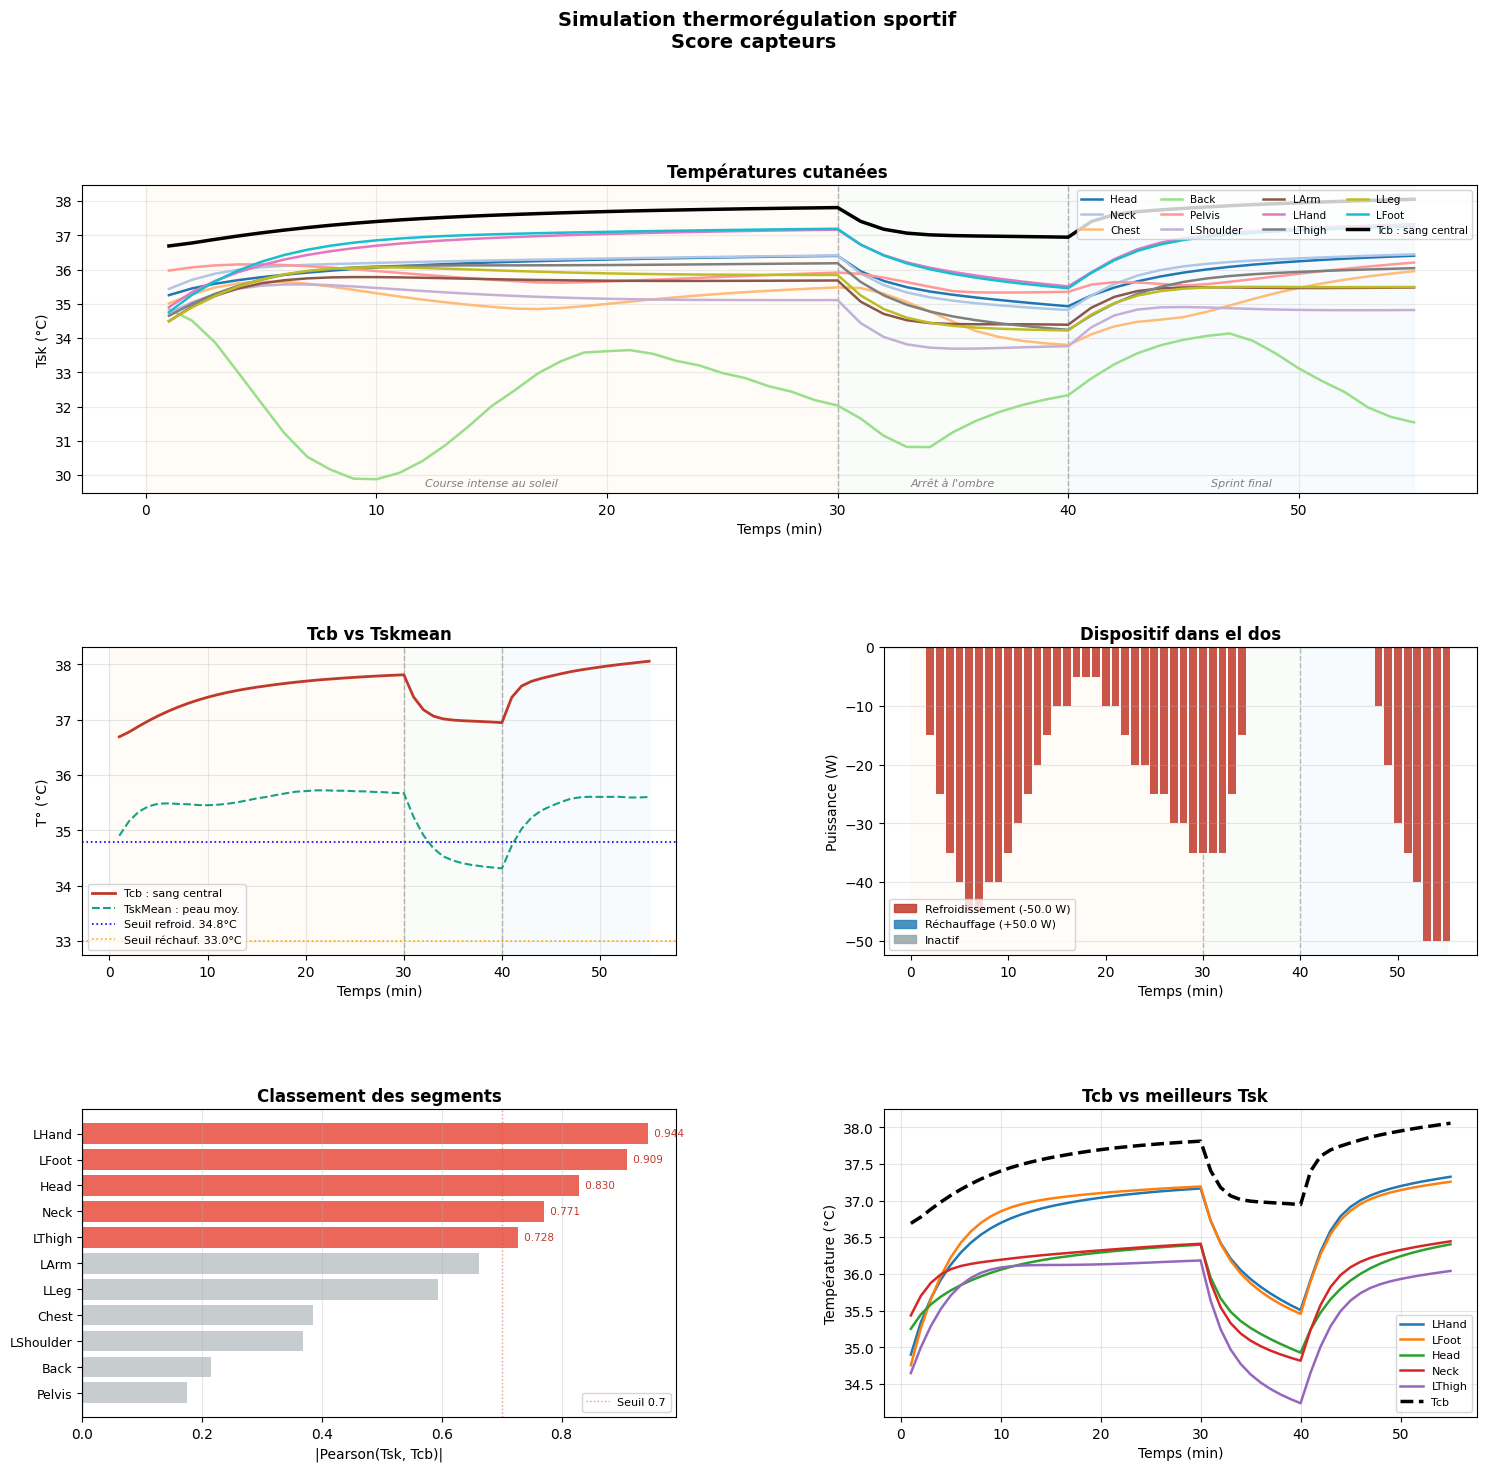

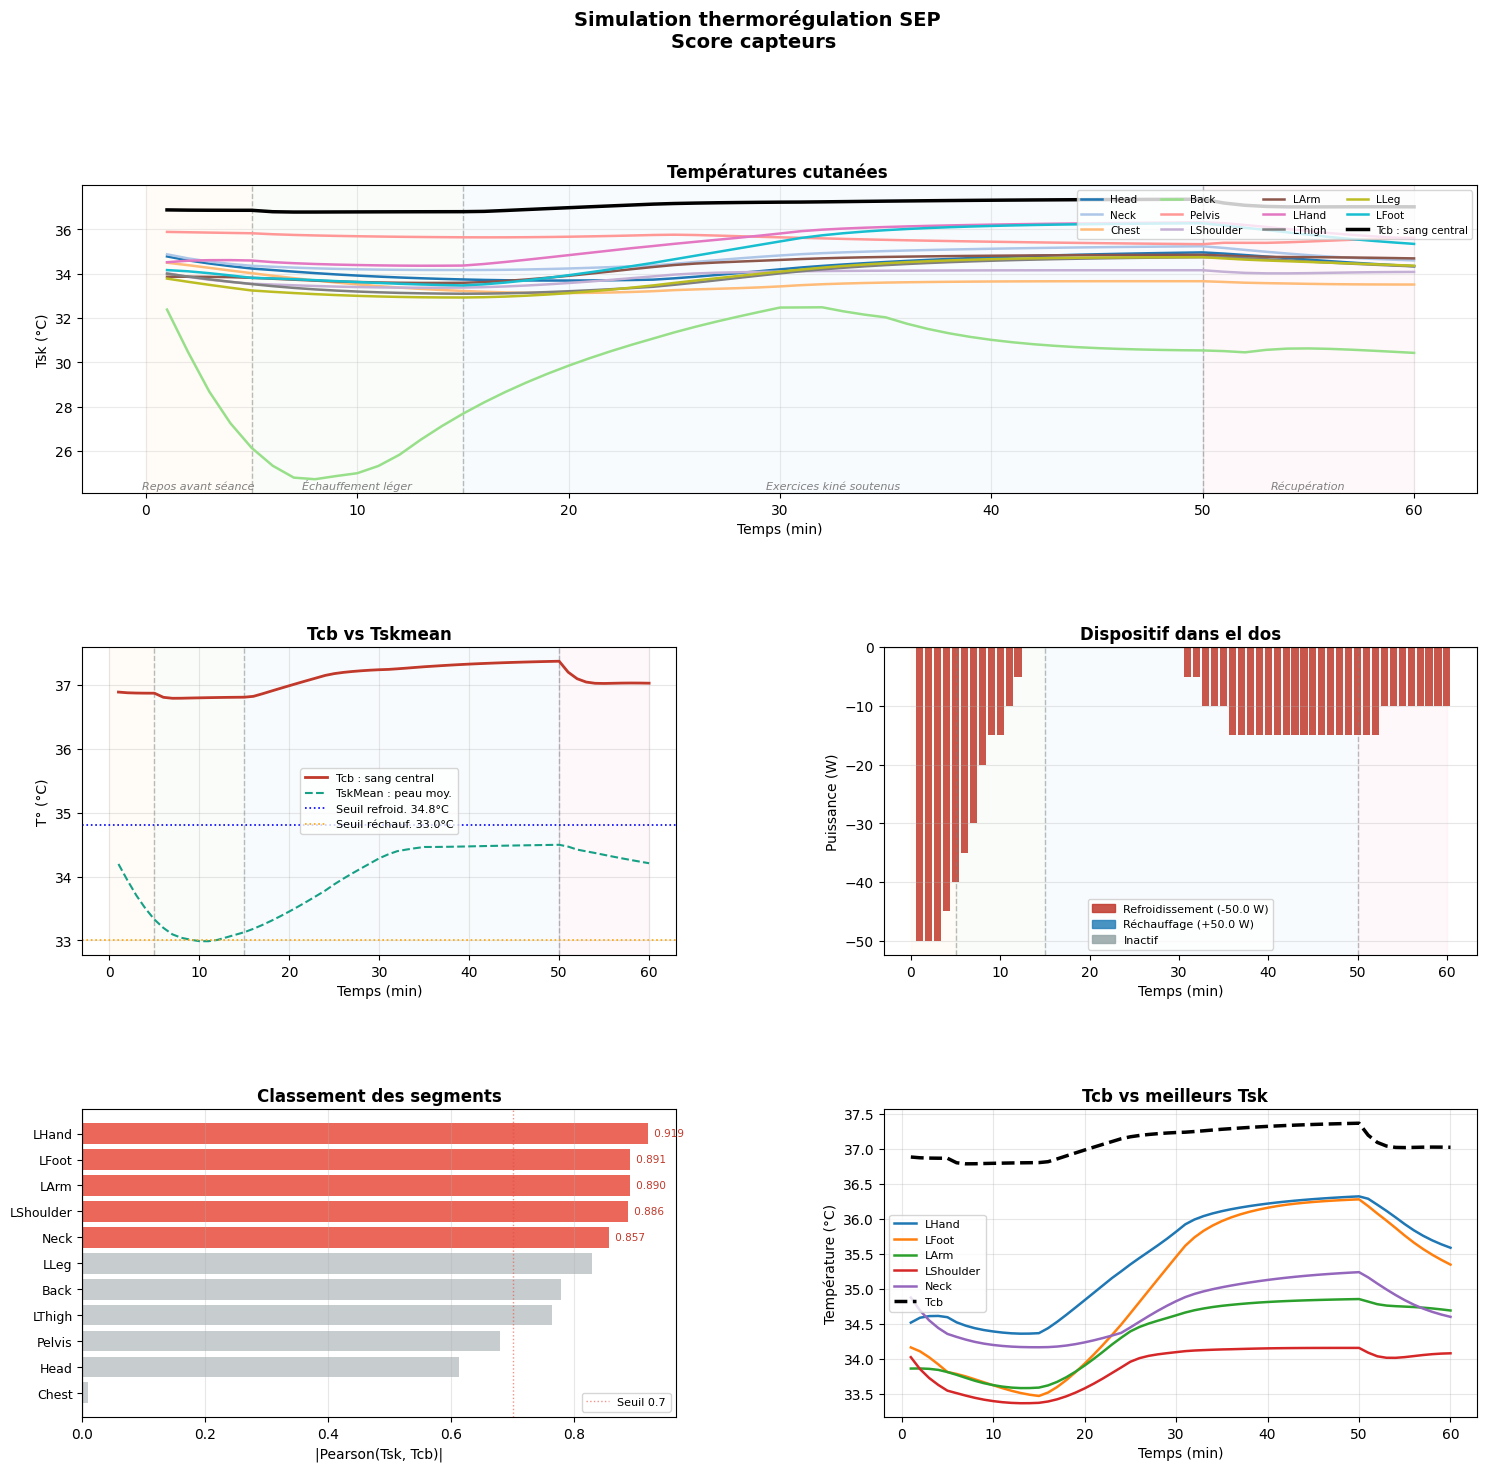

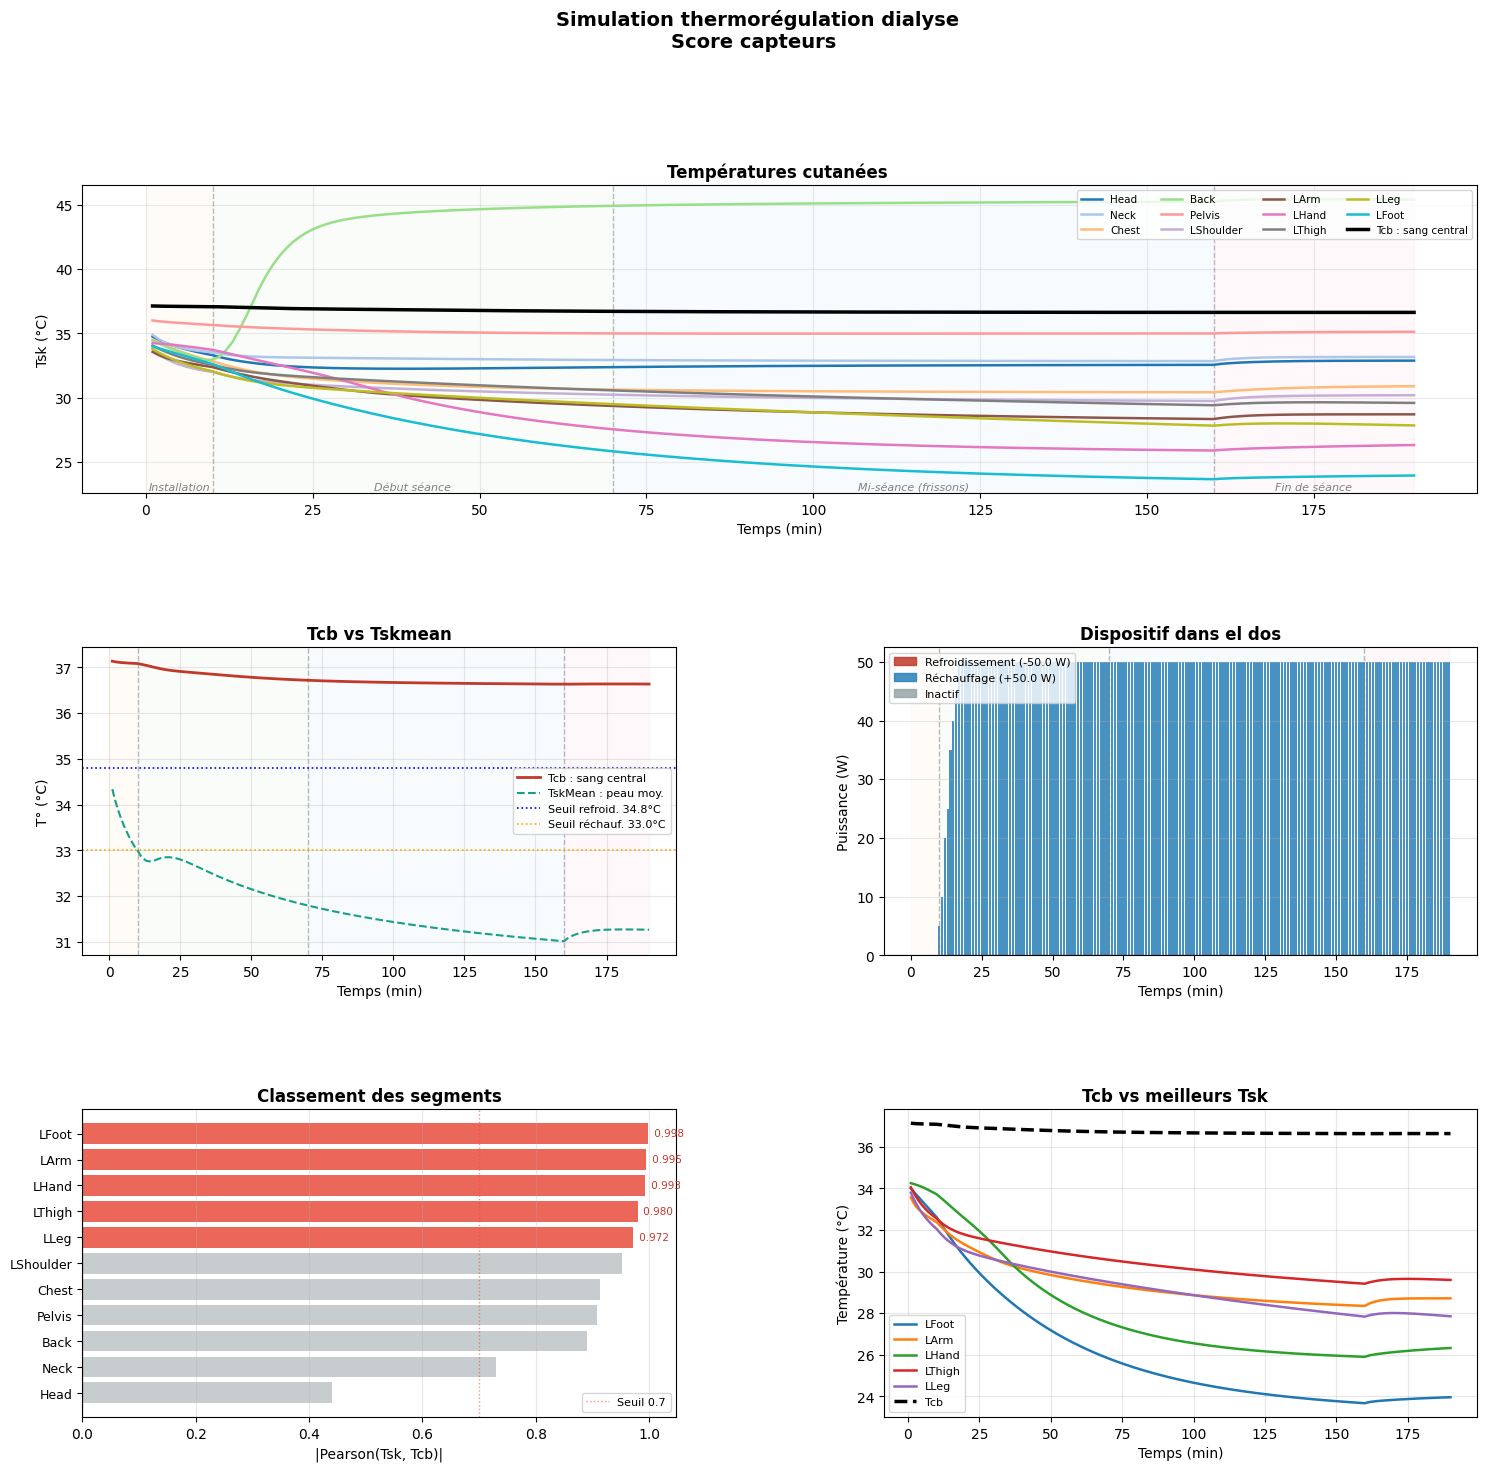


  Dispositif (sport) : Refroidissement=41min | Réchauffment=0min | Inactif=14min
  Dispositif (sep)   : Refroidissement=42min | Réchauffment=0min | Inactif=18min
  Dispositif (dial)  : Refroidissement=0min | Réchauffment=181min | Inactif=9min


In [10]:
plot_scenario(df_sport,   pb_sport,   ranked_sport,   top5_sport,   phases_sport,   "Simulation thermorégulation sportif")
plot_scenario(df_sep,     pb_sep,     ranked_sep,     top5_sep,     phases_sep,     "Simulation thermorégulation SEP")
plot_scenario(df_dialyse, pb_dialyse, ranked_dialyse, top5_dialyse, phases_dialyse, "Simulation thermorégulation dialyse")


n_cool = (df_sport["power_back"] < 0).sum()
n_heat = (df_sport["power_back"] > 0).sum()
n_off  = (df_sport["power_back"] == 0).sum()
print(f"\n  Dispositif (sport) : Refroidissement={n_cool}min | Réchauffment={n_heat}min | Inactif={n_off}min")

n_cool = (df_sep["power_back"] < 0).sum()
n_heat = (df_sep["power_back"] > 0).sum()
n_off  = (df_sep["power_back"] == 0).sum()
print(f"  Dispositif (sep)   : Refroidissement={n_cool}min | Réchauffment={n_heat}min | Inactif={n_off}min")

n_cool = (df_dialyse["power_back"] < 0).sum()
n_heat = (df_dialyse["power_back"] > 0).sum()
n_off  = (df_dialyse["power_back"] == 0).sum()
print(f"  Dispositif (dial)  : Refroidissement={n_cool}min | Réchauffment={n_heat}min | Inactif={n_off}min")